# Setup + Loading

In [1]:
import os
import json
import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt

In [2]:
def append_named_dict(filepath, name, data):
    data_str = {str(k): v for k, v in data.items()}
    with open(filepath, "a") as f:
        f.write(f"DICT:{name}={json.dumps(data_str)}\n")

def load_named_dict(filepath, name):
    with open(filepath, "r") as f:
        for line in f:
            if line.startswith(f"DICT:{name}="):
                json_str = line[len(f"DICT:{name}="):].strip()
                return json.loads(json_str)
    raise KeyError(f"{name} not found in {filepath}")

In [3]:
plt.rcParams.update({
    'figure.dpi': 150,
    'figure.figsize': (15, 7),
    'figure.facecolor': 'white',

    # minimal spines
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': '#333333',
    'axes.linewidth': 1.0,

    # subtle grid, behind data
    'axes.grid': True,
    'axes.axisbelow': True,
    'grid.linestyle': '--',
    'grid.alpha': 0.3,
    'grid.color': '#999999',

    # typography
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica Neue', 'Arial', 'DejaVu Sans'],
    'axes.titlepad': 15,   # default is ~6
    'axes.titlesize': 21,
    'axes.titleweight': 'bold',
    'axes.labelpad': 12,   # default is ~4
    'axes.labelsize': 15,
    'axes.labelcolor': '#333333',
    'xtick.color': '#555555',
    'ytick.color': '#555555',

    # color cycle for multiple lines
    'axes.prop_cycle': plt.cycler(color=[
        "#008883", "#FF0000","#C1C700", "#DDAA52", "#99889D", "#705A47"
    ]),
})

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [4]:
master_path = "/Users/fomo/Local Data/SpikesAugust2026"

session_paths = [
    master_path + "/" + file for file in os.listdir(master_path) if file != ".DS_Store"
]

In [5]:
def load_particulars(path):
    particulars = {}
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            key, _, value = line.partition("=")
            particulars[key] = value if value else None
    return particulars 

In [44]:
sessions = {}
for path in session_paths[0:1]:

    # load particulars
    particulars_path = os.path.join(path, "session_particulars.txt")
    particulars = load_particulars(particulars_path)

    # load events
    events_path = os.path.join(path, "analog_events.mat")
    events_in = sio.loadmat(events_path)

    conditions = [str(entry[0]) for entry in events_in["analog_ch_names"][0]]
    events_out = {}
    for i, condition in enumerate(conditions):
        events_out[condition] = {}
        events_out[condition]["event_timings"] = events_in["analogEvents"][0][i].squeeze()


    # load spike data
    spike_time_path = os.path.join(path, "kilosort4", "spike_times.npy")
    spike_times = np.load(spike_time_path)

    spike_pos_path = os.path.join(path, "kilosort4", "spike_positions.npy")
    spike_pos = np.load(spike_pos_path)

    spike_id_path = os.path.join(path, "kilosort4", "spike_clusters.npy")
    spike_ids = np.load(spike_id_path)

    spike_clusters_path = os.path.join(path, "kilosort4", "cluster_group.tsv")
    spike_clusters = pd.read_csv(spike_clusters_path, sep="\t")
    
    # store session data in dictionary
    sessions[path] = {
        "name": path,
        "particulars": particulars,
        "events": events_out,
        "spike_times": spike_times,
        "spike_positions": spike_pos,
        "spike_ids": spike_ids,
        "spike_clusters": spike_clusters
    }

# Load Session

In [45]:
session = sessions[session_paths[0]]

particulars = session["particulars"]
spike_times = session["spike_times"]
spike_positions = session["spike_positions"]
spike_ids = session["spike_ids"]
spike_clusters = session["spike_clusters"]
events = session["events"]

def describe_variable(name: str, obj) -> str:
    if isinstance(obj, pd.DataFrame):
        dtypes_str = ", ".join(f"{col}={dt}" for col, dt in obj.dtypes.items())
        return f"{name:<20} shape={obj.shape}, dtypes=({dtypes_str})"
    else:
        return f"{name:<20} shape={obj.shape}, dtype={obj.dtype}"


print("=" * 120)
print("SESSION DATA SUMMARY")
print("=" * 120)
print(f"Session name : {session['name']}")
print(f"Particulars  : {particulars}")

print("\n--- Spike data ---")
print(describe_variable("Spike Times", spike_times))
print(describe_variable("Spike Positions", spike_positions))
print(f"Electrode Depth (min,max)", spike_positions[:, 1].min(0), spike_positions[:, 1].max(0))

print(describe_variable("Spike IDs", spike_ids))
print(describe_variable("Cluster Groups", spike_clusters))
print(spike_clusters["KSLabel"].value_counts()) 

print("\n--- Analog data ---")
print(f"{'Analog Channels':<20} {conditions}")
print(f"{'Analog Shape':<20} {[event["event_timings"].shape for event in events.values()]}")
print("=" * 120)

SESSION DATA SUMMARY
Session name : /Users/fomo/Local Data/SpikesAugust2026/2026-04-14_11-46-55
Particulars  : {'thetaCh': '54', 'CA1Ch': '69', 'V1L4Ch': '27', 'DGsCh': '103', 'DGiCh': None, 'bad_channels': None, 'DICT:contaminated_ratios': '{"20": 0.102, "23": 0.21, "25": 0.132, "27": 0.37, "30": 0.157, "49": 0.479, "50": 0.233, "57": 0.232, "77": 0.204, "89": 0.324, "90": 0.311, "103": 0.155, "108": 0.119, "109": 0.124, "128": 0.652, "138": 0.461, "142": 0.124, "170": 0.182}'}

--- Spike data ---
Spike Times          shape=(3755190,), dtype=int64
Spike Positions      shape=(3755190, 2), dtype=float32
Electrode Depth (min,max) 25.138775 2576.9873
Spike IDs            shape=(3755190,), dtype=int32
Cluster Groups       shape=(207, 2), dtypes=(cluster_id=int64, KSLabel=str)
KSLabel
mua     162
good     45
Name: count, dtype: int64

--- Analog data ---
Analog Channels      ['static', 'phase_reversing_1', 'running_wheel', 'flicker_40Hz', 'phase_reversing_2', 'flicker_20Hz', 'none', 'photod

# EDA

## Parameters

In [8]:
FS = 30_000  
BIN_MS      = 0.5    # histogram bin width (ms)
WINDOW_MS   = 50.0   # ACG half-window (ms) — ±50 ms 
SETTLE_S    = 300.0  # first 5 min = settling

## Autocorrelogram & Refractory Ratios

In [9]:
def autocorrelogram(spike_samples, fs=FS, bin_ms=BIN_MS, window_ms=WINDOW_MS, plot = False):
    """
    ACG for one unit. spike_samples: sorted int sample numbers for THIS unit only.
    Returns bin_centres [ms], counts. No self-pairs (i != j), symmetric about 0.
    """
    t = np.sort(spike_samples) / fs * 1000.0          # -> milliseconds
    edges   = np.arange(-window_ms, window_ms + bin_ms, bin_ms)
    counts  = np.zeros(len(edges) - 1, dtype=np.int64)

    # np.searchsorted keeps this O(N * neighbours), not O(N^2).
    lo = np.searchsorted(t, t - window_ms, side="left")
    hi = np.searchsorted(t, t + window_ms, side="right")
    for i in range(len(t)):
        lags = t[lo[i]:hi[i]] - t[i]                  # includes 0 (self) and both signs
        lags = lags[lags != 0.0]                      # drop the i == j self-pair
        counts += np.histogram(lags, bins=edges)[0]

    centres = (edges[:-1] + edges[1:]) / 2

    # plot (optional)

    if plot == True:
        fig, ax = plt.subplots(figsize=(15, 7))
        ax.bar(centres, acg, width=BIN_MS, align="center")
        ax.axvspan(-2.5, 2.5, color="crimson", alpha=0.5, label="±2.5 ms refractory zone")
        for k in (-25, 25):  # 40 Hz period marks
            ax.axvline(k, color="red", ls="--", lw=0.8)
        ax.set_xlabel("Lag τ [ms]"); ax.set_ylabel("Pair count")
        ax.set_title(f"ACG for Unit {unit}, n={n_sp} spikes", fontsize = 21)
        ax.legend(fontsize=8)
        plt.tight_layout(); plt.show()

    return centres, counts

In [10]:
good_ids = spike_clusters.loc[spike_clusters["KSLabel"] == "good", "cluster_id"].values

In [11]:
def refractory_ratio(unit_id, spike_ids, spike_times, flank_ms = 15):
    """
    Computes refractory ratio for a single unit (unit_id)
    Returns refractory ratio
    """

    mask = (spike_times >= (SETTLE_S * FS)) & (spike_ids == unit_id)
    unit_spikes = spike_times[mask]

    centres, acg = autocorrelogram(unit_spikes)

    refractory = np.abs(centres) <= 2.5
    flank = (np.abs(centres) > 2.5) & (np.abs(centres) < flank_ms)

    refractory_ratios = np.mean(acg[refractory])/np.mean(acg[flank])

    return refractory_ratios

dict_keys([20, 23, 25, 27, 30, 49, 50, 57, 77, 89, 90, 103, 108, 109, 128, 138, 142, 170])


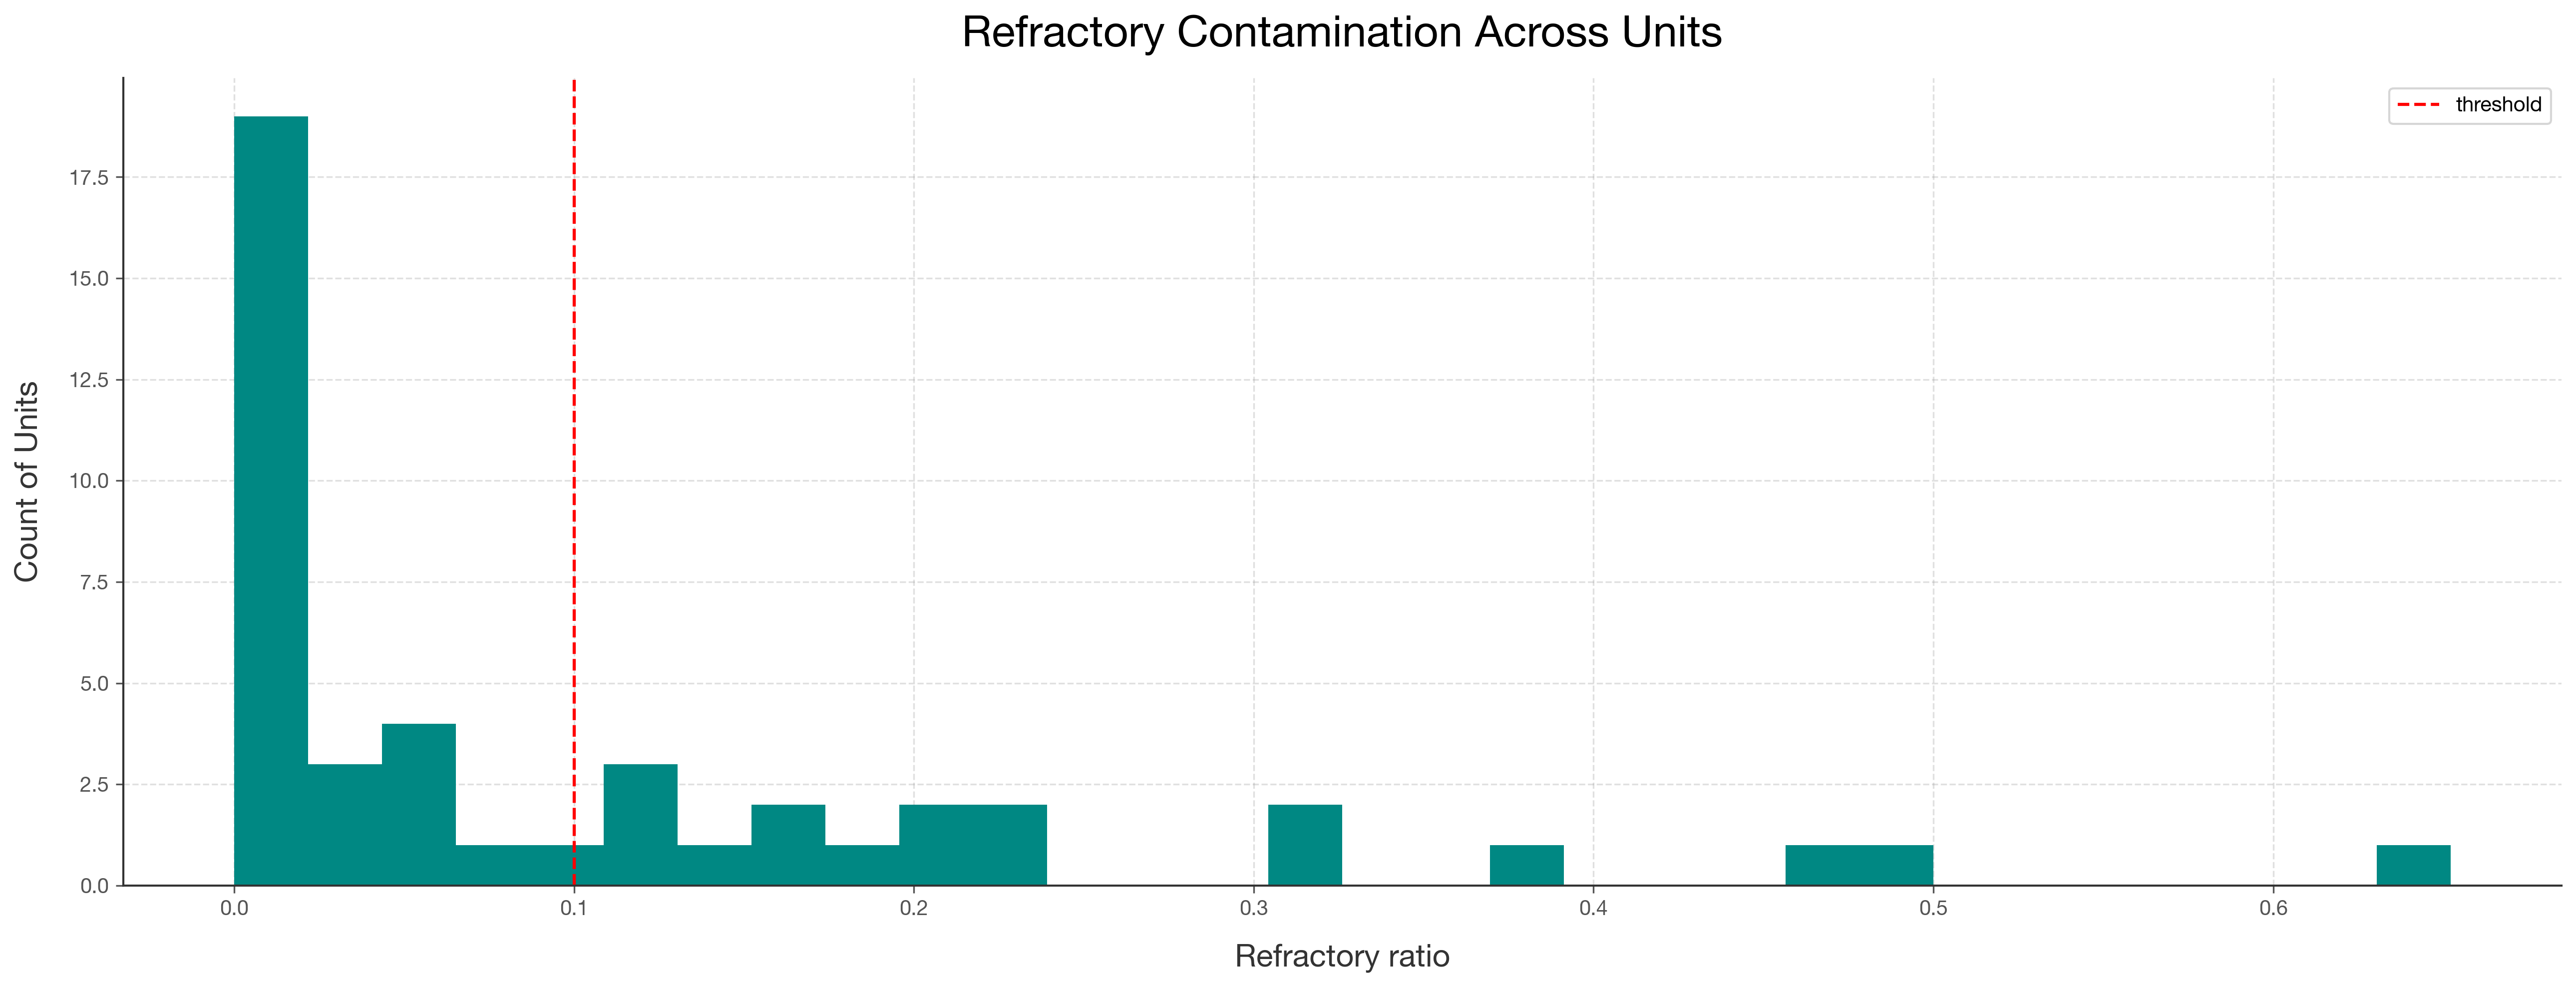

In [12]:
ratios = []
contaminated = {}

for uid in good_ids:
    ratio = refractory_ratio(uid, spike_ids, spike_times)
    ratios.append(ratio)
    if ratio > 0.1:
        contaminated[int(uid)] = round(float(ratio), 3)

print(contaminated.keys())

fig1, ax1 = plt.subplots(figsize = (21, 7))
ax1.hist(ratios, bins=30)
ax1.axvline(0.1, color='red', linestyle='--', label='threshold')
ax1.set_xlabel('Refractory ratio')
ax1.set_ylabel('Count of Units')
ax1.set_title('Refractory Contamination Across Units')
ax1.legend()
plt.show()

In [14]:
append_named_dict(particulars_path, "contaminated_ratios", contaminated)

In [75]:
contaminated = load_named_dict(particulars_path, "contaminated_ratios")
contaminated_ids = list(contaminated.keys())

## Peri-Stimulus Time Histogram

In [48]:
for condition, event_data in events.items():
    event_times = np.asarray(event_data["event_timings"]).ravel()
    print(f"\n{condition}: n={event_times.size}")
    if event_times.size >= 3:
        d = np.diff(np.sort(event_times)) / FS * 1000    # inter-onset intervals [ms]
        print(f"  first 5 onsets (s): {np.sort(event_times)[:5]/FS}")
        print(f"  inter-onset ms — median {np.median(d):.2f}, min {d.min():.2f}, max {d.max():.2f}")


static: n=185
  first 5 onsets (s): [283.52836667 297.54746667 311.57063333 325.58943333 339.60826667]
  inter-onset ms — median 4001.15, min 5.10, max 52089.70

phase_reversing_1: n=9600
  first 5 onsets (s): [353.64356667 353.66853333 353.6935     353.71883333 353.7435    ]
  inter-onset ms — median 25.00, min 24.53, max 52141.80

running_wheel: n=53416
  first 5 onsets (s): [0.0003     0.00873333 0.0168     0.0246     0.03186667]
  inter-onset ms — median 6.37, min 2.10, max 14558.27

flicker_40Hz: n=9610
  first 5 onsets (s): [287.53346667 295.54276667 301.55206667 309.56193333 315.5754    ]
  inter-onset ms — median 25.00, min 24.57, max 52150.23

phase_reversing_2: n=9600
  first 5 onsets (s): [353.656      353.681      353.706      353.731      353.75603333]
  inter-onset ms — median 25.00, min 24.80, max 52141.67

flicker_20Hz: n=4805
  first 5 onsets (s): [291.53826667 305.55706667 319.58016667 333.59906667 347.6176    ]
  inter-onset ms — median 50.00, min 49.53, max 52170.7

In [58]:
def get_block_onsets(event_times, gap_ms=250):
    t = np.sort(np.asarray(event_times).ravel().astype(np.int64))
    gaps = np.diff(t) / FS * 1000
    onsets = np.concatenate(([True], gaps > gap_ms))
    cycles_per_block = t.size / onsets.sum()
    return t[onsets], cycles_per_block

In [61]:
for condition in events.keys():

    if condition in ("none", "photodiode", "running_wheel"):
        continue

    event_times = events[condition]["event_timings"]

    block_onsets, n_cycles = get_block_onsets(event_times)

    events[condition]["block start (s)"] = block_onsets/FS
    events[condition]["cycles per block"] = n_cycles

In [77]:
PRE_S, POST_S = 0.5, 3.5
BIN = 0.025
BASE_LO, BASE_HI = -0.5, 0.0
MIN_SPIKES = 100


clean_ids = good_ids[~np.isin(good_ids, np.array(contaminated_ids, dtype=int))]


In [69]:
def psth_rate(spike_samples, onset_samples, fs=FS):
    spk = np.sort(spike_samples).astype(np.int64)
    edges = np.arange(-PRE_S, POST_S + BIN, BIN)
    counts = np.zeros(len(edges)-1, dtype=np.int64)
    lo = np.searchsorted(spk, onset_samples - int(PRE_S*fs))
    hi = np.searchsorted(spk, onset_samples + int(POST_S*fs))
    for k, on in enumerate(onset_samples):
        rel = (spk[lo[k]:hi[k]] - on)/fs
        counts += np.histogram(rel, bins=edges)[0]
    centres = (edges[:-1]+edges[1:])/2
    return centres, counts/(BIN*len(onset_samples))

In [78]:
def zscored_matrix(condition, clean_ids):
    """rows = clean units (>=MIN_SPIKES, non-flat baseline), z-scored envelope."""
    onsets = np.sort(np.asarray(events[condition]["block start (s)"]).ravel()*FS).astype(np.int64)
    rows, kept = [], []
    for u in clean_ids:
        sel = spike_times[spike_ids == u]
        if sel.size < MIN_SPIKES:
            continue
        c, r = psth_rate(sel, onsets)
        b = (c>=BASE_LO)&(c<BASE_HI)
        mu, sd = r[b].mean(), r[b].std()
        if sd == 0:
            continue
        rows.append((r-mu)/sd); kept.append(u)
    return c, np.array(rows), np.array(kept)

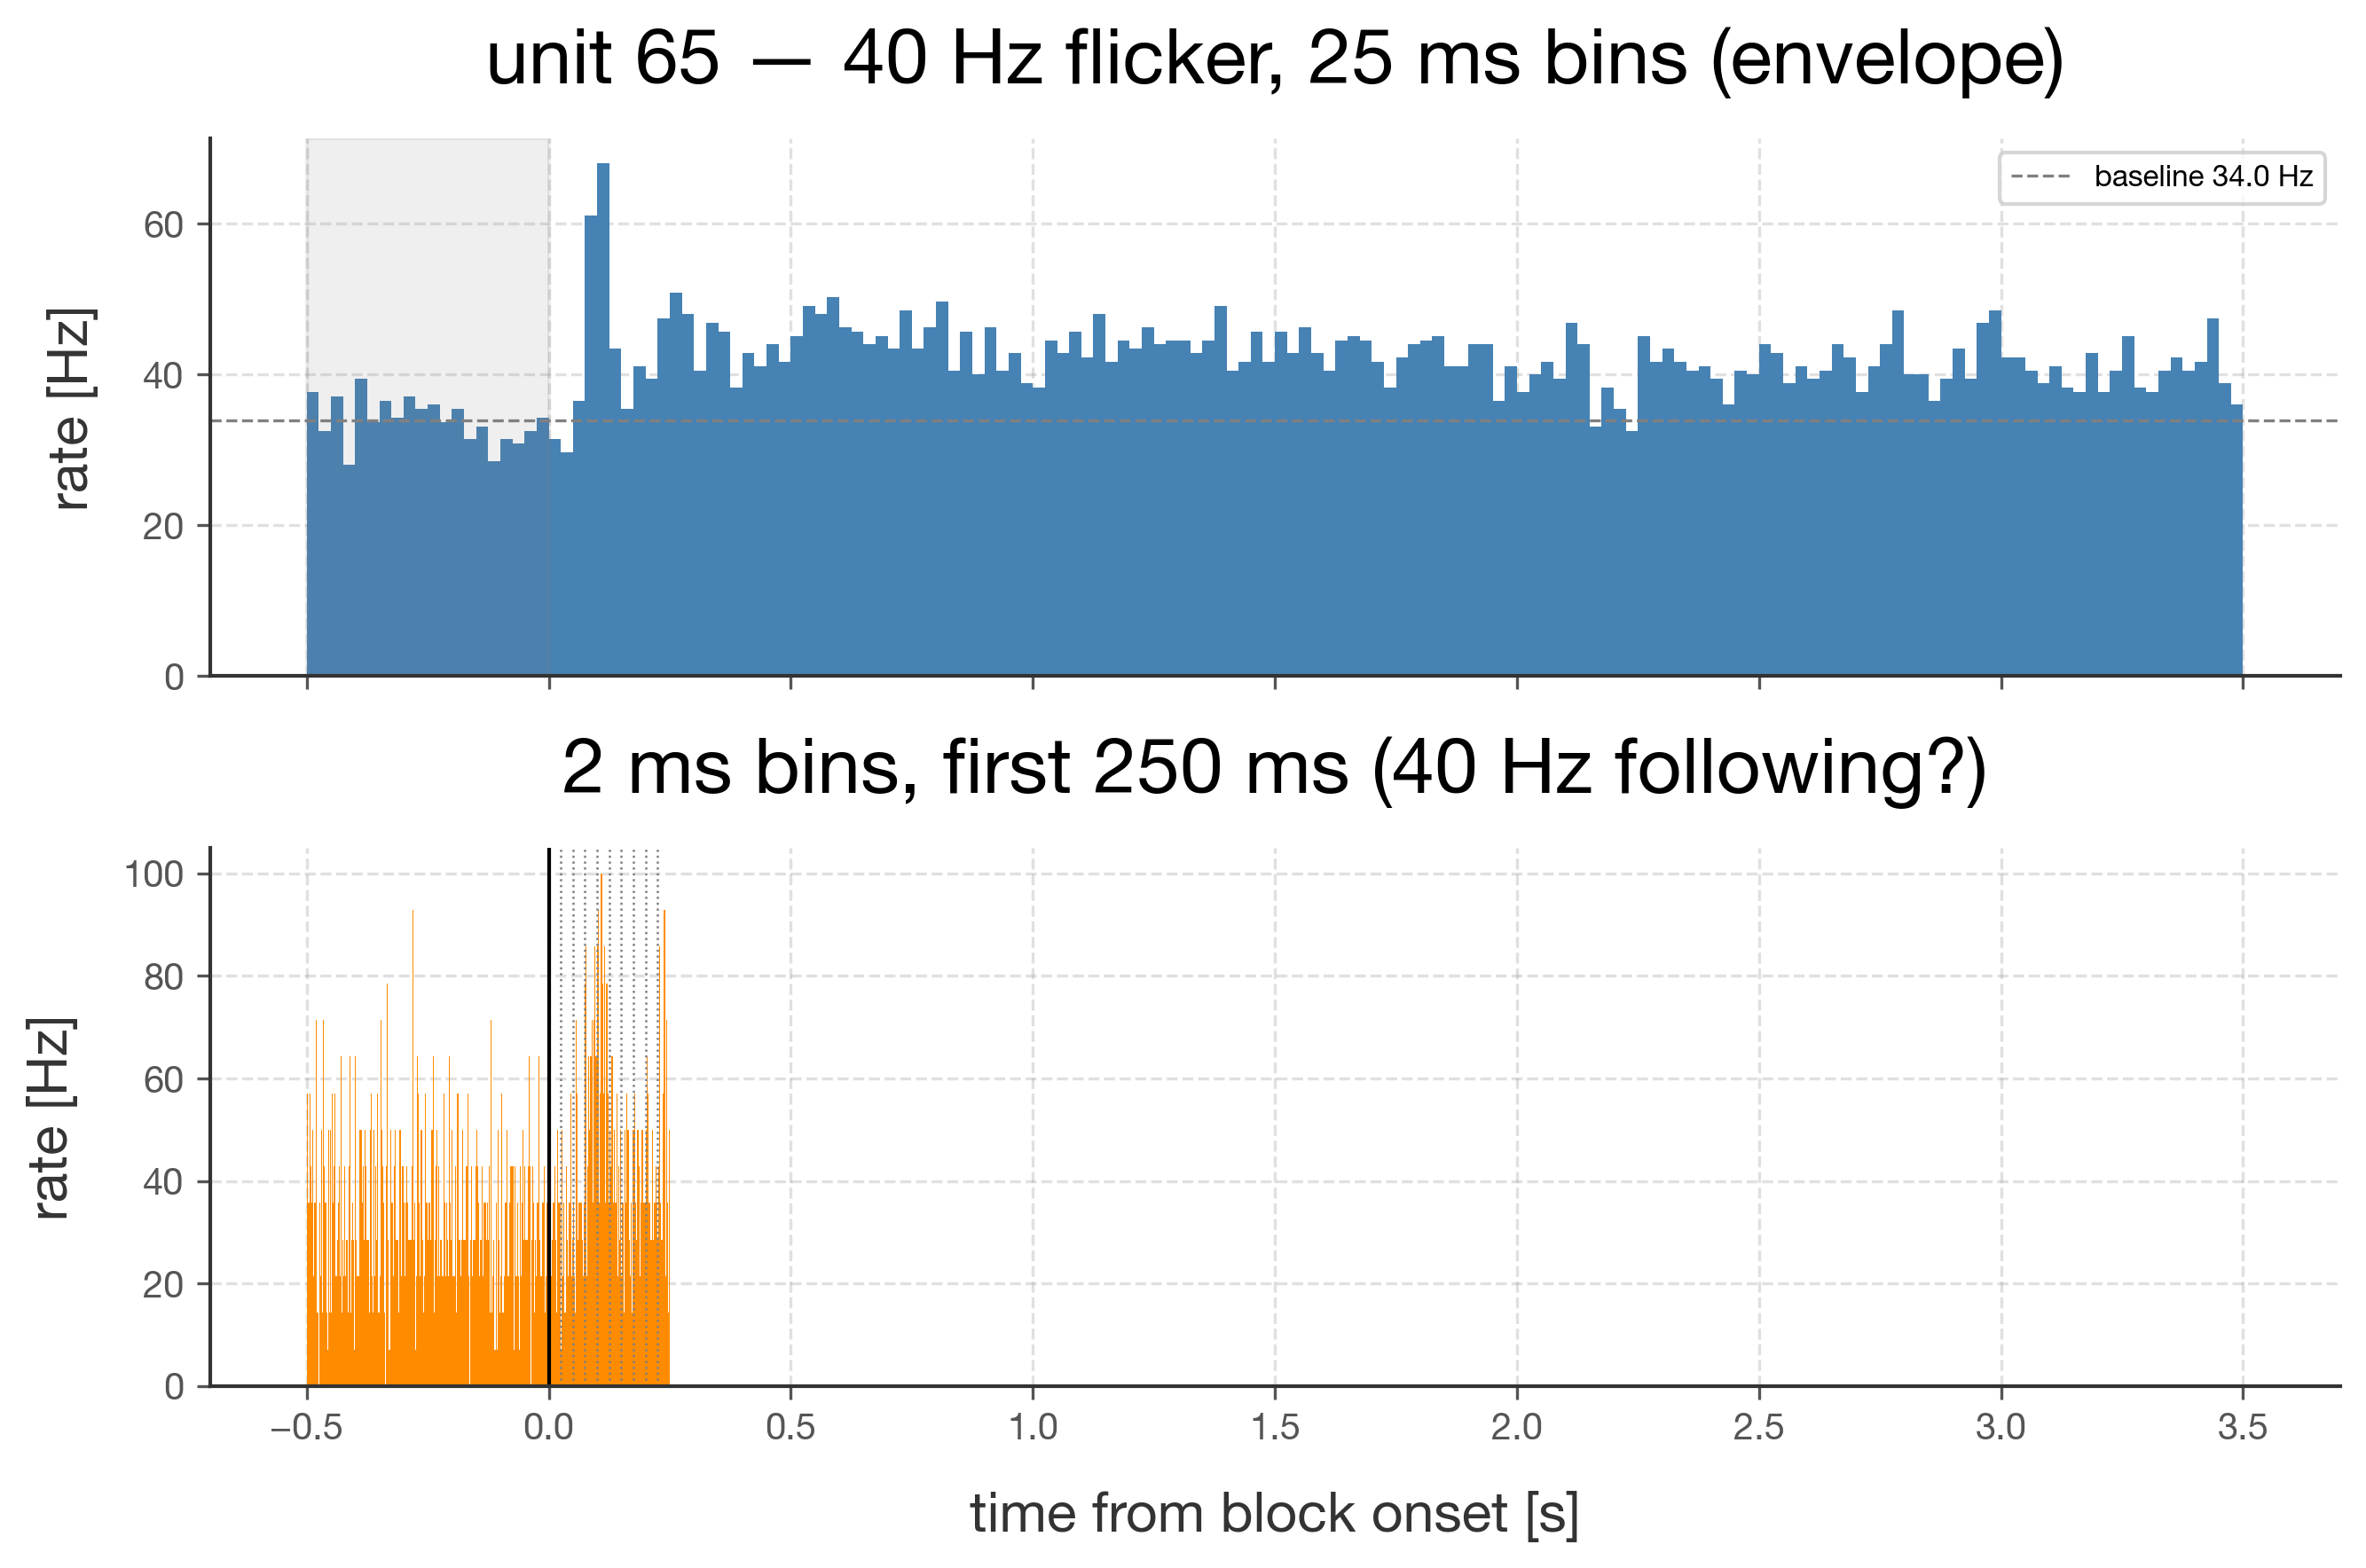

unit 65: baseline 34.0 Hz, peak envelope 68.0 Hz


In [64]:

# ---- pick the same top 'good' unit as the ACG ----
good_ids = spike_clusters.loc[spike_clusters["KSLabel"]=="good","cluster_id"].values
mask_settled = spike_times >= 300*FS
unit = max(good_ids, key=lambda u: np.sum((spike_ids==u)&mask_settled))
sel  = spike_times[(spike_ids==unit)]

# ---- compute both bin scales ----
c_coarse, r_coarse = psth(sel, blk40, PRE_S, POST_S, BIN_COARSE)
c_fine,   r_fine   = psth(sel, blk40, PRE_S, POST_S, BIN_FINE)

# baseline for the envelope (z-score vs pre-onset)
b = (c_coarse>=BASE_LO)&(c_coarse<BASE_HI)
mu, sd = r_coarse[b].mean(), r_coarse[b].std()

# ---- plot ----
fig, ax = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
ax[0].bar(c_coarse, r_coarse, width=BIN_COARSE, color="steelblue")
ax[0].axhline(mu, color="grey", ls="--", lw=0.8, label=f"baseline {mu:.1f} Hz")
ax[0].axvspan(BASE_LO, BASE_HI, color="grey", alpha=0.12)
ax[0].set_ylabel("rate [Hz]"); ax[0].set_title(f"unit {unit} — 40 Hz flicker, 25 ms bins (envelope)")
ax[0].legend(fontsize=8)

# fine PSTH — zoom to first 250 ms so 40 Hz structure is visible (whole block would be a smear)
zoom = c_fine <= 0.25
ax[1].bar(c_fine[zoom], r_fine[zoom], width=BIN_FINE, color="darkorange")
for k in np.arange(0, 0.25, 0.025):   # 40 Hz cycle marks
    ax[1].axvline(k, color="grey", ls=":", lw=0.6)
ax[1].axvline(0, color="k", lw=1)
ax[1].set_xlabel("time from block onset [s]"); ax[1].set_ylabel("rate [Hz]")
ax[1].set_title("2 ms bins, first 250 ms (40 Hz following?)")
plt.tight_layout(); plt.show()

print(f"unit {unit}: baseline {mu:.1f} Hz, peak envelope {r_coarse.max():.1f} Hz")